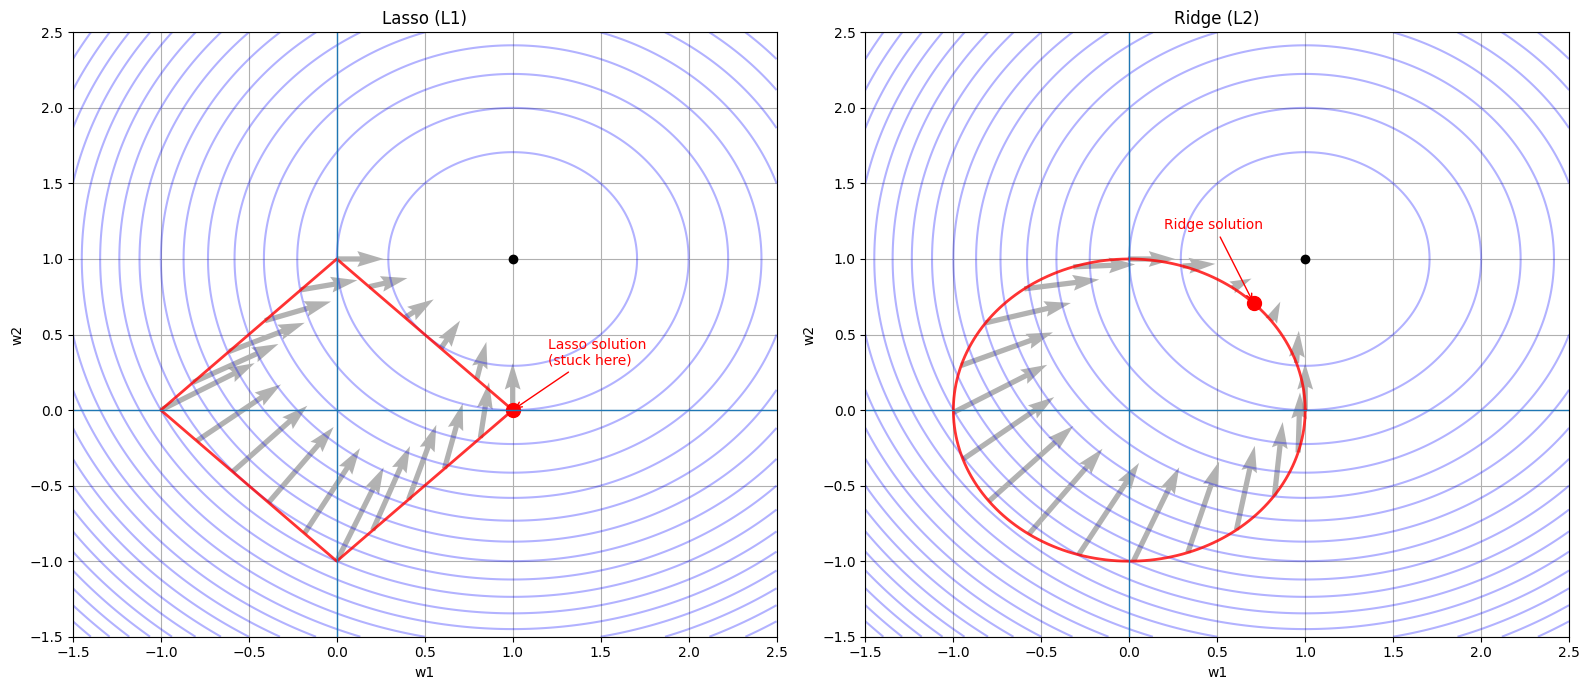

In [1]:
# Question 2.2
import numpy as np
import matplotlib.pyplot as plt

def get_grad(w1, w2):
    return -(w1 - 1), -(w2 - 1)

w_range = np.linspace(-1.5, 2.5, 200)
w1, w2 = np.meshgrid(w_range, w_range)

loss = (w1 - 1)**2 + (w2 - 1)**2

l1_w1 = np.concatenate([
    np.linspace(1, 0, 50),
    np.linspace(0, -1, 50),
    np.linspace(-1, 0, 50),
    np.linspace(0, 1, 50)
])
l1_w2 = np.concatenate([
    np.linspace(0, 1, 50),
    np.linspace(1, 0, 50),
    np.linspace(0, -1, 50),
    np.linspace(-1, 0, 50)
])

theta = np.linspace(0, 2*np.pi, 200)
ridge_w1 = np.cos(theta)
ridge_w2 = np.sin(theta)

w_star = np.array([1, 1]) 
lasso_opt = np.array([1, 0])
ridge_opt = np.array([1/np.sqrt(2), 1/np.sqrt(2)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.contour(w1, w2, loss, levels=30, colors='blue', alpha=0.3)
ax1.plot(l1_w1, l1_w2, 'r-', alpha=0.8, linewidth=2)
gw1, gw2 = get_grad(l1_w1, l1_w2)
ax1.quiver(l1_w1[::10], l1_w2[::10], gw1[::10], gw2[::10],
           color='grey', alpha=0.6, scale=15)
ax1.plot(*w_star, 'ko', markersize=6)
ax1.plot(*lasso_opt, 'ro', markersize=10)
ax1.annotate("Lasso solution\n(stuck here)",
             xy=lasso_opt, xytext=(1.2, 0.3),
             arrowprops=dict(arrowstyle="->", color='red'),
             color='red')

ax1.axhline(0, linewidth=1)
ax1.axvline(0, linewidth=1)

ax1.set_title("Lasso (L1)")
ax1.set_xlabel("w1")
ax1.set_ylabel("w2")
ax1.grid(True)

ax2.contour(w1, w2, loss, levels=30, colors='blue', alpha=0.3)
ax2.plot(ridge_w1, ridge_w2, 'r-', alpha=0.8, linewidth=2)
gw1, gw2 = get_grad(ridge_w1, ridge_w2)
ax2.quiver(ridge_w1[::10], ridge_w2[::10], gw1[::10], gw2[::10],
           color='grey', alpha=0.6, scale=15)
ax2.plot(*w_star, 'ko', markersize=6)
ax2.plot(*ridge_opt, 'ro', markersize=10)
ax2.annotate("Ridge solution",
             xy=ridge_opt, xytext=(0.2, 1.2),
             arrowprops=dict(arrowstyle="->", color='red'),
             color='red')

ax2.axhline(0, linewidth=1)
ax2.axvline(0, linewidth=1)

ax2.set_title("Ridge (L2)")
ax2.set_xlabel("w1")
ax2.set_ylabel("w2")
ax2.grid(True)

plt.tight_layout()
plt.show()

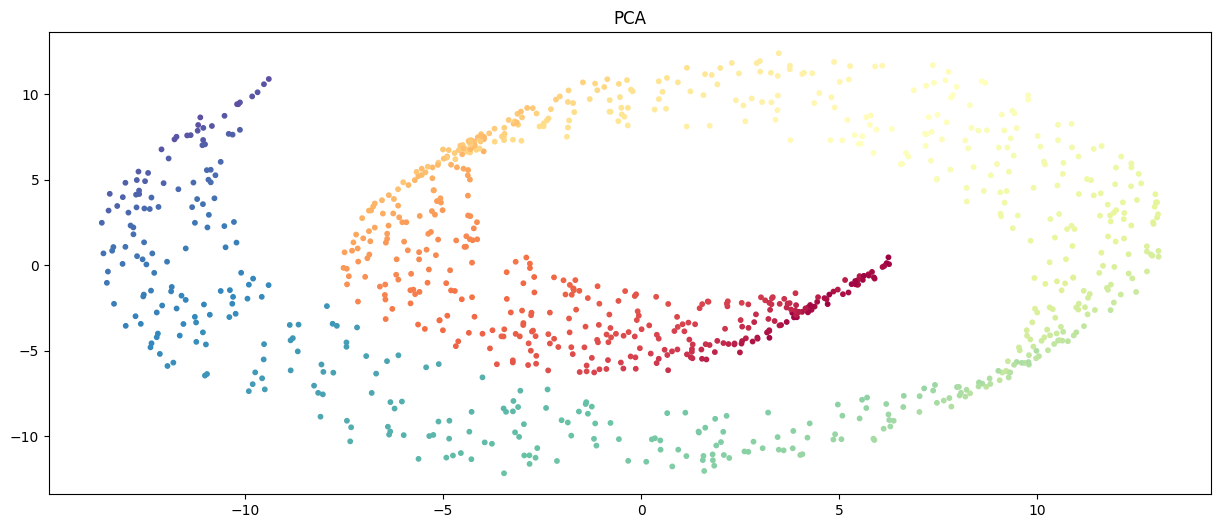

In [6]:
# Programming: Dimensionality Reduction
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

seed = 42
n_samples = 1000
X, color = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=seed)

# PCA
def pca(X, color):
    X_cted = X - np.mean(X, axis=0)
    n_samples = X.shape[0]
    Sigma = (X_cted.T @ X_cted) / n_samples
    eigen_values, eigen_vectors = np.linalg.eigh(Sigma)
    indices = np.argsort(eigen_values)[::-1]
    eigen_values = eigen_values[indices[:2]]
    U = eigen_vectors[:, indices[:2]]

    X_ld = X_cted @ U
    plt.figure(figsize=(15, 6))
    plt.scatter(X_ld[:, 0], X_ld[:, 1], c=color, cmap=plt.cm.Spectral, s=10)
    plt.title("PCA")
    plt.show()

pca(X, color)

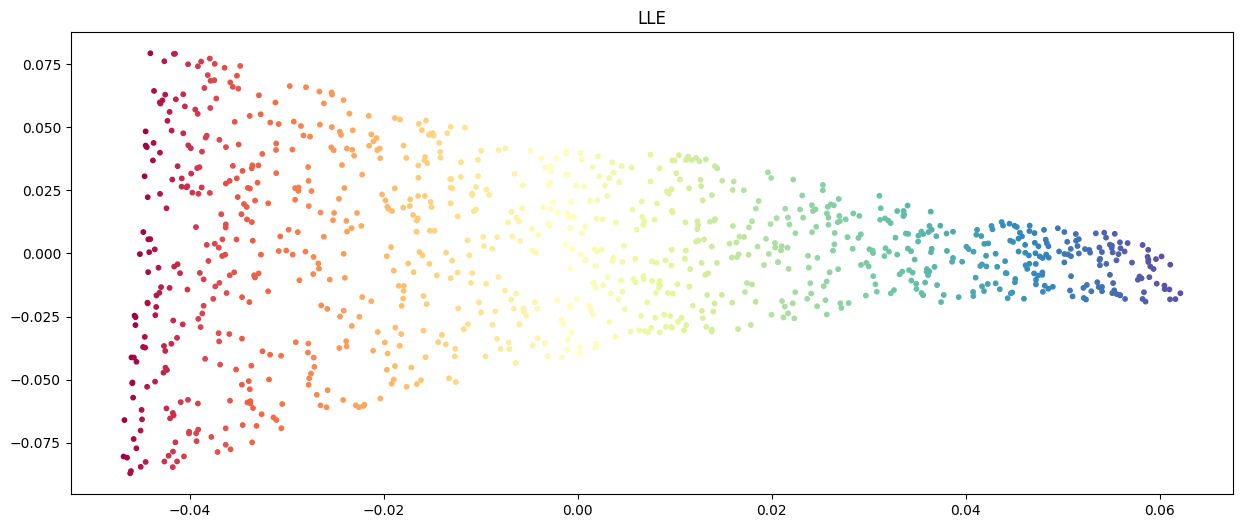

In [7]:
# LLE
from sklearn.neighbors import NearestNeighbors

n_neighbors = 10
def lle(X, color, n_neighbors=10):
    knn = NearestNeighbors(n_neighbors=n_neighbors)
    knn.fit(X)
    _, indices = knn.kneighbors(X)

    W = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        n_indices = indices[i]
        Y = X[i] - X[n_indices]
        G = Y @ Y.T
        G += np.eye(n_neighbors) * 1e-3 * np.trace(G)
        w = np.linalg.solve(G, np.ones(n_neighbors))
        w /= w.sum()
        W[i, n_indices] = w

    F = np.eye(n_samples) - W
    Sigma_z = F.T @ F
    eigen_values, eigen_vectors = np.linalg.eigh(Sigma_z)
    eigen_indices = np.argsort(eigen_values)
    Z = eigen_vectors[:, eigen_indices[1:3]]

    plt.figure(figsize=(15, 6))
    plt.scatter(Z[:, 0], Z[:, 1], c=color, cmap=plt.cm.Spectral, s=10)
    plt.title("LLE")
    plt.show()

lle(X, color, n_neighbors)

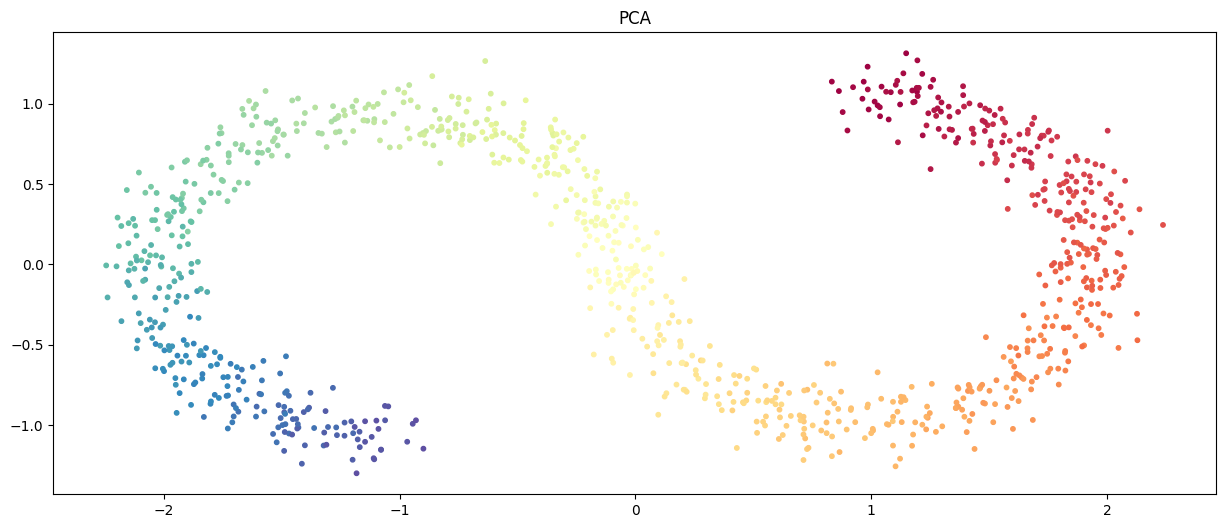

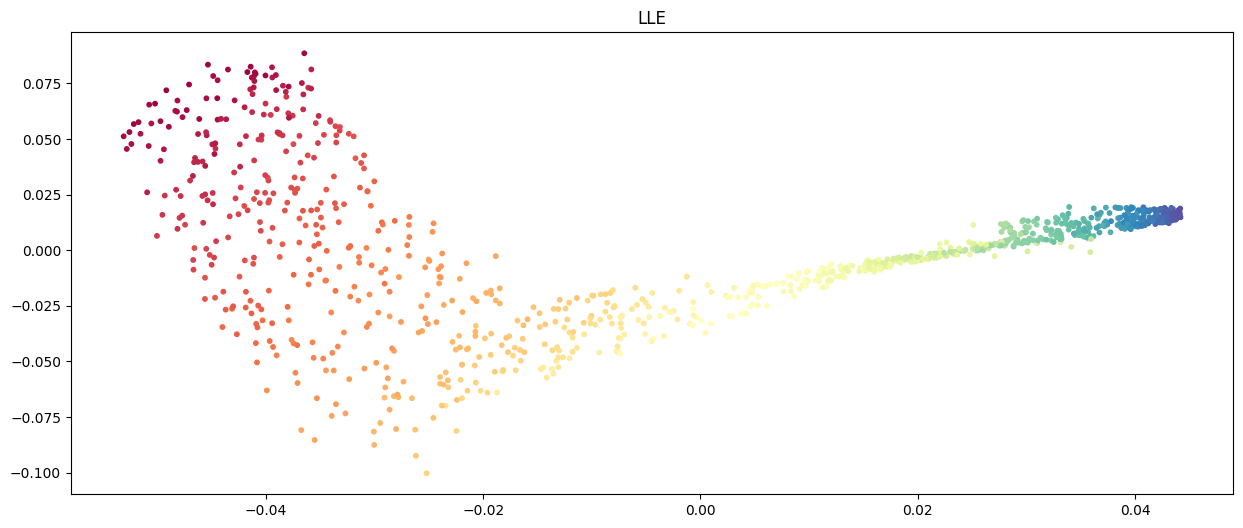

In [ ]:
from sklearn.datasets import make_s_curve

X, color = make_s_curve(n_samples=n_samples, noise=0.1, random_state=seed)
pca(X, color)
lle(X, color, n_neighbors)

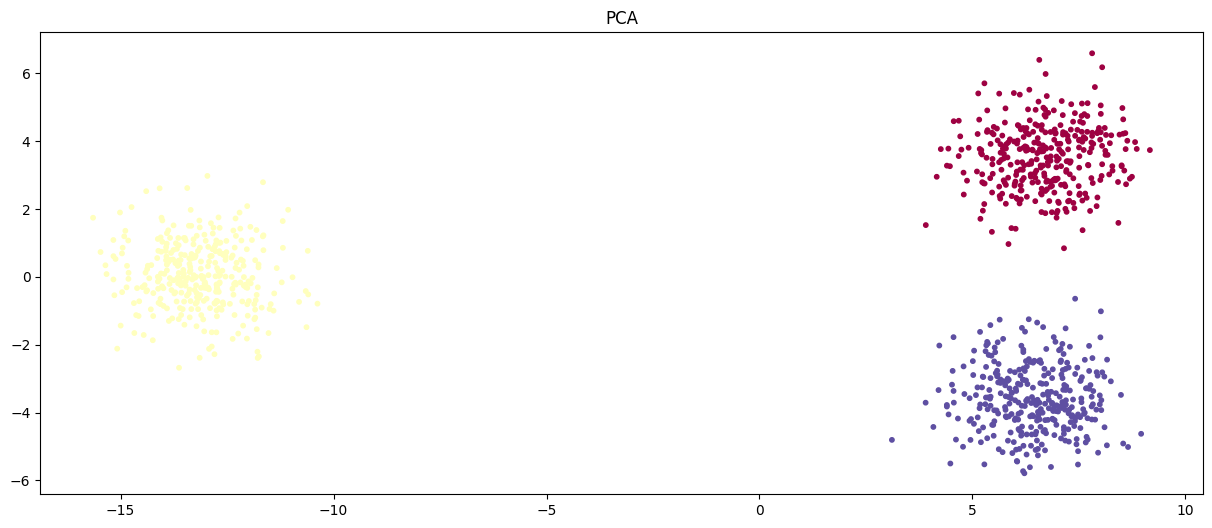

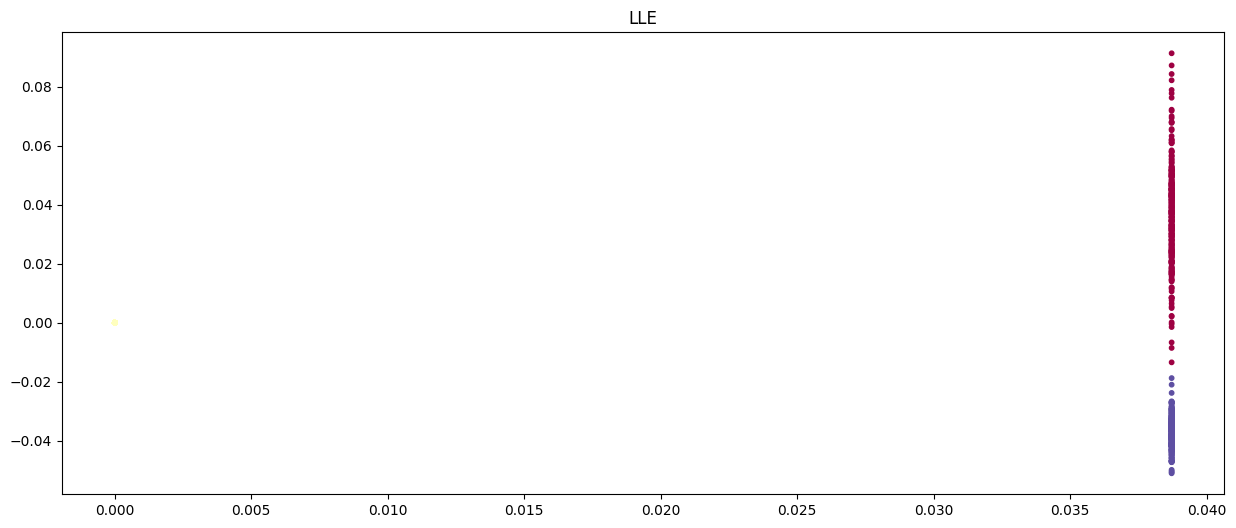

In [29]:
from sklearn.datasets import make_blobs

X, color = make_blobs(n_samples=n_samples, n_features=3, centers=3, cluster_std=1.0, random_state=seed)
pca(X, color)
lle(X, color, n_neighbors)